In [204]:
import pandas as pd
from tools.utils import *
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import paired_cosine_distances
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import numpy as np
import torch
import spacy
sns.set()

In [205]:
df_cosm = pd.read_excel('xls_files/modifications_cosmetic.xlsx', sheet_name='Sheet2')
df_subs = pd.read_excel('xls_files/modifications_meaning.xlsx', sheet_name='Sheet2')
df_meaning = pd.read_excel('xls_files/modifications_meaning 2.xlsx', sheet_name='Sheet2')
df_x = pd.read_excel('xls_files/modifications_X_full.xlsx', sheet_name='Sheet2')

In [206]:
df_cosm['type'] = 'cosmetic'
df_subs['type'] = 'subs'
df_meaning['type'] = 'meaning'
df_x['type'] = 'x'

In [207]:
model = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True) # trust_remote_code is needed to use the encode method


/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- configuration_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- modeling_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
<All keys matched successfully>


In [208]:
def compute_distances(df,model,col1, col2):
    
    embeddings1 = model.encode([ f'clustering: {s}'for s in df[col1].tolist()])
    embeddings2 = model.encode([ f'clustering: {s}'for s in df[col2].tolist()])

    distances = 1 - paired_cosine_distances(embeddings1,embeddings2)
    return distances


In [209]:
df_meaning['distances'] = compute_distances(df_meaning,model,'Original','Human Modified')
df_subs['distances'] = compute_distances(df_subs,model,'Original','Human Modified')
df_cosm['distances'] = compute_distances(df_cosm,model,'Original','Human Modified')
df_x['distances'] = compute_distances(df_x,model,'Before','After')

<Axes: xlabel='type', ylabel='distances'>

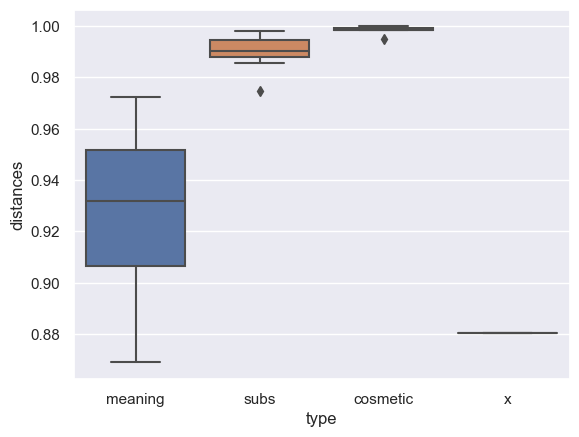

In [210]:
data = pd.concat([df_meaning,df_subs,df_cosm,df_x],axis=0, ignore_index=True)
sns.boxplot(x='type', y='distances', data=data)

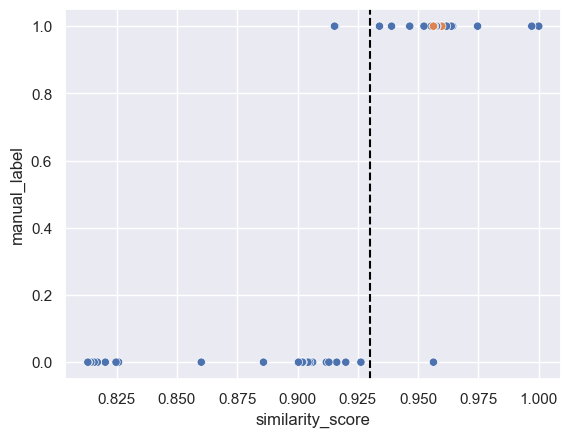

In [213]:
from matplotlib import pyplot as plt
pair_annotations_1 = pd.read_excel('xls_files/pairs_to_annotate_TS.xlsx', sheet_name='pairs_to_annotate')
pair_annotations_2 = pd.read_excel('xls_files/pairs_to_annotate_round_2_TS.xlsx', sheet_name='pairs_to_annotate_round_2')
pair_annotations = pd.concat([pair_annotations_1,pair_annotations_2],axis=0, ignore_index=True)
pair_annotations['colour'] = 'blue'
pair_annotations.loc[pair_annotations.label != pair_annotations.manual_label,'colour'] = 'red'
sns.scatterplot(y='manual_label', x='similarity_score',hue='colour',data=pair_annotations, legend=False)
plt.axvline(.93, 0, 1, color='black', linestyle='--')

In [214]:
pair_annotations['score'] = 0
pair_annotations.loc[pair_annotations.similarity_score >= 0.93,'score'] = 1

In [215]:
from sklearn.metrics import classification_report
print(classification_report(pair_annotations.manual_label, pair_annotations.score))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        26
           1       0.96      0.92      0.94        24

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50



In [216]:
sentences = list(Path('xls_files/sentences').glob('*.xlsx'))

In [217]:
sentences

[PosixPath('xls_files/sentences/modifications_meaning_limitation[7].xlsx'),
 PosixPath('xls_files/sentences/modifications_X_jurisdiction[1].xlsx'),
 PosixPath('xls_files/sentences/modifications_meaning_lang[37].xlsx'),
 PosixPath('xls_files/sentences/modifications_meaning_arb[92].xlsx'),
 PosixPath('xls_files/sentences/modifications_cosmetic_mod[97].xlsx')]

In [219]:
dfs = []
for sentence in sentences:
    df = pd.read_excel(sentence, sheet_name='Sheet2')
    df['similarity_score'] = compute_distances(df,model,'Original','Modified')
    dfs.append(df)


In [220]:
pd.concat(dfs, axis=0, ignore_index=True).to_csv('sentences_similarity.csv', index=False)